# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a widely used **dimensionality reduction** technique in machine learning, data analysis, and statistics. Its primary goal is to **reduce the number of variables** in a dataset while preserving as much **information (variance)** as possible.



<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2012/Session%2012_1%20-%20Model%20Evaluation%20and%20Refinement.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2012/Session%2012_1%20-%20Model%20Evaluation%20and%20Refinement.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>


---

## 🧠 Goal of PCA

The main objectives of PCA are:
- **Reduce dimensionality**: Transform a large set of features into a smaller one that still contains most of the information in the original dataset.
- **Identify patterns**: Reveal hidden structure in the data by identifying directions (principal components) along which the data varies the most.
- **Eliminate redundancy**: Remove multicollinearity by combining correlated features into uncorrelated components.
- **Improve efficiency**: Speed up machine learning algorithms and visualization by simplifying the feature space.

## ⚙️ How PCA Works (High-Level Overview)

1. **Standardize the data**: PCA is affected by scale, so features are usually standardized (mean = 0, variance = 1).
2. **Compute the covariance matrix**: This matrix expresses how features vary together.
3. **Calculate eigenvectors and eigenvalues**: These determine the directions (principal components) and magnitude of variance in each direction.
4. **Sort eigenvectors**: Eigenvectors are ranked by their corresponding eigenvalues, from highest to lowest variance.
5. **Project the data**: The original data is transformed onto a new feature space formed by the top *k* eigenvectors (principal components).


## PCA Review



<img src='PCA.png' />

## Libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_breast_cancer

## The Data

Let's work with the cancer dataset again since it had so many features.

In [2]:
cancer = load_breast_cancer()
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [3]:
print(cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [4]:
df = pd.DataFrame(cancer['data'],columns=cancer['feature_names'])
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

## 📌 PCA Parameters

The `PCA` class in `scikit-learn` provides several important parameters that control how Principal Component Analysis is performed.

| Parameter | Type | Description |
|-----------|------|-------------|
| `n_components` | int, float, None, or str | Number of components to keep. Can be: <br>• `int`: number of components (e.g., 2) <br>• `float`: percentage of variance to preserve (e.g., 0.95) <br>• `'mle'`: automatically selects components using MLE (requires `svd_solver='full'`) <br>• `None`: all components are kept |
| `copy` | bool (default=True) | If False, data passed to `fit` will be overwritten. |
| `whiten` | bool (default=False) | When True, the components are scaled to have unit variance. Useful for some ML models, but can distort feature relationships. |
| `svd_solver` | {'auto', 'full', 'arpack', 'randomized'} | Solver to use for the decomposition: <br>• `'auto'`: chooses automatically based on data and parameters <br>• `'full'`: exact full SVD <br>• `'arpack'`: truncated SVD (for sparse data or large n_components) <br>• `'randomized'`: faster approximation for large datasets |
| `tol` | float (default=0.0) | Tolerance for stopping when using `svd_solver='arpack'`. |
| `iterated_power` | int or 'auto' (default='auto') | Number of iterations for the power method when `svd_solver='randomized'`. |
| `random_state` | int, RandomState instance or None | Controls randomness for reproducibility (only used with `svd_solver='randomized'`). |

---


In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(scaled_data)

In [7]:
x_pca.shape

(569, 2)

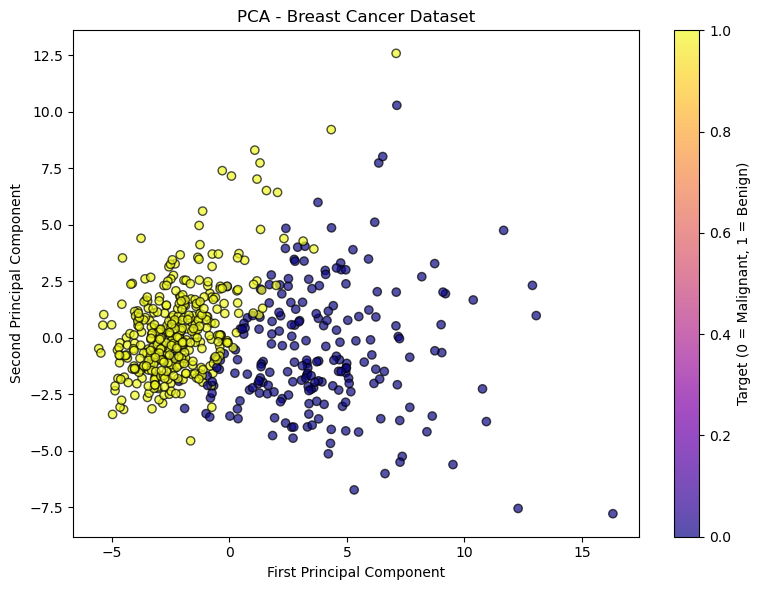

In [8]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=cancer.target,
    cmap='plasma',
    edgecolor='k',
    alpha=0.7
)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA - Breast Cancer Dataset')
plt.colorbar(scatter, label='Target (0 = Malignant, 1 = Benign)')
plt.tight_layout()

Clearly by using these two components we can easily separate these two classes.

## Interpreting the components 

Unfortunately, with this great power of dimensionality reduction, comes the cost of being able to easily understand what these components represent.

In [11]:
pca.components_

array([[ 0.21890244,  0.10372458,  0.22753729,  0.22099499,  0.14258969,
         0.23928535,  0.25840048,  0.26085376,  0.13816696,  0.06436335,
         0.20597878,  0.01742803,  0.21132592,  0.20286964,  0.01453145,
         0.17039345,  0.15358979,  0.1834174 ,  0.04249842,  0.10256832,
         0.22799663,  0.10446933,  0.23663968,  0.22487053,  0.12795256,
         0.21009588,  0.22876753,  0.25088597,  0.12290456,  0.13178394],
       [-0.23385713, -0.05970609, -0.21518136, -0.23107671,  0.18611302,
         0.15189161,  0.06016536, -0.0347675 ,  0.19034877,  0.36657547,
        -0.10555215,  0.08997968, -0.08945723, -0.15229263,  0.20443045,
         0.2327159 ,  0.19720728,  0.13032156,  0.183848  ,  0.28009203,
        -0.21986638, -0.0454673 , -0.19987843, -0.21935186,  0.17230435,
         0.14359317,  0.09796411, -0.00825724,  0.14188335,  0.27533947]])

In this numpy matrix array, each row represents a principal component, and each column relates back to the original features.

In [10]:
df_comp = pd.DataFrame(pca.components_,columns=cancer['feature_names'])

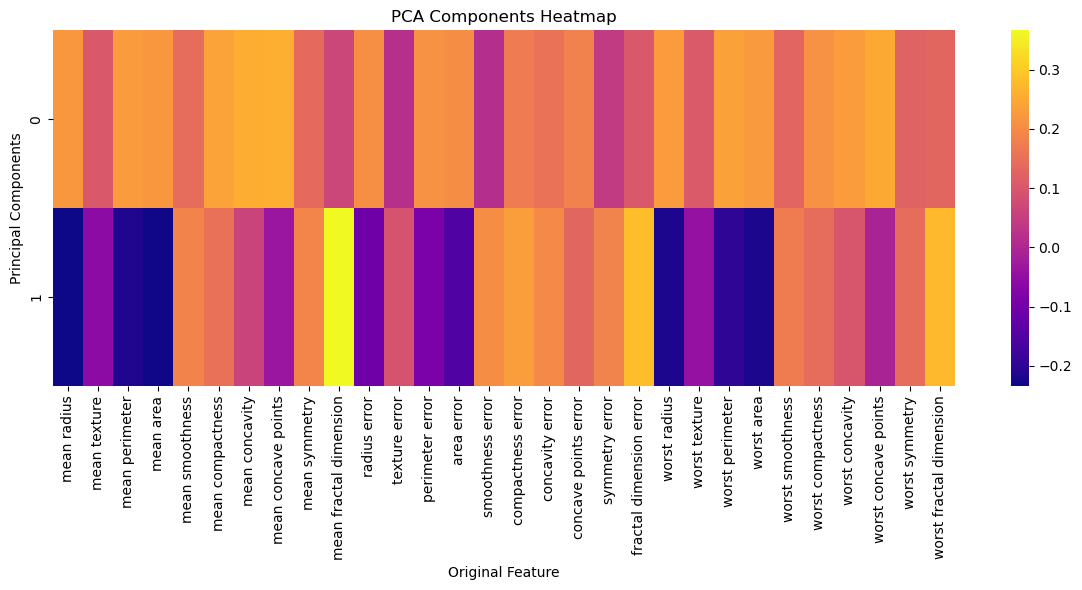

In [12]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_comp, cmap='plasma')
plt.title('PCA Components Heatmap')
plt.xlabel('Original Feature')
plt.ylabel('Principal Components')
plt.tight_layout()

This heatmap and the color bar basically represent the correlation between the various feature and the principal component itself.

# Great Job!

<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2006/Session%2006%20-%20Matplotlib%20Concepts_1.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>